
# Análisis supervisado con SVM — Wisconsin Diagnostic Breast Cancer (WDBC)

**Nombre del dataset:** Wisconsin Diagnostic Breast Cancer (WDBC)  
**Fuente:** UCI Machine Learning Repository  
**Liga de acceso:** https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

El dataset contiene información obtenida a partir de imágenes digitalizadas de aspiraciones con aguja fina (FNA) de masas mamarias. Sus variables describen características de los núcleos celulares presentes en dichas imágenes.

Cada registro representa una muestra correspondiente a una masa mamaria analizada. La variable objetivo es **`diagnosis`**, que indica si el diagnóstico es:

- **B:** benigno
- **M:** maligno

Las variables predictoras corresponden a 30 características numéricas derivadas de diez propiedades de los núcleos celulares: radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal. Para cada propiedad se incluyen medidas de media, error estándar y valor *worst*.

La variable **`id`** funciona únicamente como identificador de cada registro, por lo que no se utilizará como predictora.

## Preguntas de análisis

**Pregunta para el análisis supervisado:**  
¿Es posible predecir si una masa mamaria es benigna o maligna a partir de sus características numéricas utilizando modelos SVM?

**Pregunta para el análisis no supervisado:**  
¿Es posible identificar grupos naturales de muestras con características celulares similares sin utilizar la etiqueta de diagnóstico?


## 1. Importación de librerías

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)


## 2. Carga del dataset

In [ ]:

from google.colab import files

uploaded = files.upload()

columnas = [
    'id', 'diagnosis',
    'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
    'mean_smoothness', 'mean_compactness', 'mean_concavity',
    'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension',
    'se_radius', 'se_texture', 'se_perimeter', 'se_area',
    'se_smoothness', 'se_compactness', 'se_concavity',
    'se_concave_points', 'se_symmetry', 'se_fractal_dimension',
    'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area',
    'worst_smoothness', 'worst_compactness', 'worst_concavity',
    'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension'
]

df = pd.read_csv("wdbc.data", header=None, names=columnas)
df.head()


Saving wdbc.data to wdbc.data


,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,se_radius,se_texture,se_perimeter,se_area,se_smoothness,se_compactness,se_concavity,se_concave_points,se_symmetry,se_fractal_dimension,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Revisión inicial de la estructura

In [ ]:

print("Número de registros:", df.shape[0])
print("Número de columnas:", df.shape[1])
print("\nVariables disponibles:")
print(df.columns.tolist())


Número de registros: 569
Número de columnas: 32

Variables disponibles:
['id', 'diagnosis', 'mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'se_radius', 'se_texture', 'se_perimeter', 'se_area', 'se_smoothness', 'se_compactness', 'se_concavity', 'se_concave_points', 'se_symmetry', 'se_fractal_dimension', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension']


### Primeras observaciones

In [ ]:
df.head()

,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,se_radius,se_texture,se_perimeter,se_area,se_smoothness,se_compactness,se_concavity,se_concave_points,se_symmetry,se_fractal_dimension,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Últimas observaciones

In [ ]:
df.tail()

,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,se_radius,se_texture,se_perimeter,se_area,se_smoothness,se_compactness,se_concavity,se_concave_points,se_symmetry,se_fractal_dimension,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


### Tipos de datos

In [ ]:
df.dtypes

,0
id,int64
diagnosis,object
mean_radius,float64
mean_texture,float64
mean_perimeter,float64
mean_area,float64
mean_smoothness,float64
mean_compactness,float64
mean_concavity,float64
mean_concave_points,float64


### Estadísticas descriptivas

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
mean_radius,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
mean_texture,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
mean_perimeter,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
mean_area,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
mean_smoothness,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
mean_compactness,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
mean_concavity,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
mean_concave_points,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
mean_symmetry,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


### Valores faltantes

In [ ]:

faltantes = df.isnull().sum()
print(faltantes)
print("\nValores faltantes totales:", faltantes.sum())


id                         0
diagnosis                  0
mean_radius                0
mean_texture               0
mean_perimeter             0
mean_area                  0
mean_smoothness            0
mean_compactness           0
mean_concavity             0
mean_concave_points        0
mean_symmetry              0
mean_fractal_dimension     0
se_radius                  0
se_texture                 0
se_perimeter               0
se_area                    0
se_smoothness              0
se_compactness             0
se_concavity               0
se_concave_points          0
se_symmetry                0
se_fractal_dimension       0
worst_radius               0
worst_texture              0
worst_perimeter            0
worst_area                 0
worst_smoothness           0
worst_compactness          0
worst_concavity            0
worst_concave_points       0
worst_symmetry             0
worst_fractal_dimension    0
dtype: int64

Valores faltantes totales: 0



**Interpretación:**  
No se identificaron valores faltantes en el dataset. Por lo tanto, no es necesario aplicar imputación ni eliminar observaciones por información incompleta, y pueden conservarse los registros disponibles para el modelado.


### Registros duplicados

In [ ]:

duplicados = df.duplicated().sum()
print("Registros duplicados:", duplicados)


Registros duplicados: 0



**Interpretación:**  
No se identificaron registros completamente duplicados, por lo que no se requiere eliminar observaciones por este motivo.


### Distribución de la variable objetivo

In [ ]:

conteo_clases = df["diagnosis"].value_counts()
porcentaje_clases = df["diagnosis"].value_counts(normalize=True).mul(100).round(2)

distribucion = pd.DataFrame({
    "Frecuencia": conteo_clases,
    "Porcentaje (%)": porcentaje_clases
})

distribucion


,Frecuencia,Porcentaje (%)
diagnosis,,
B,357,62.74
M,212,37.26


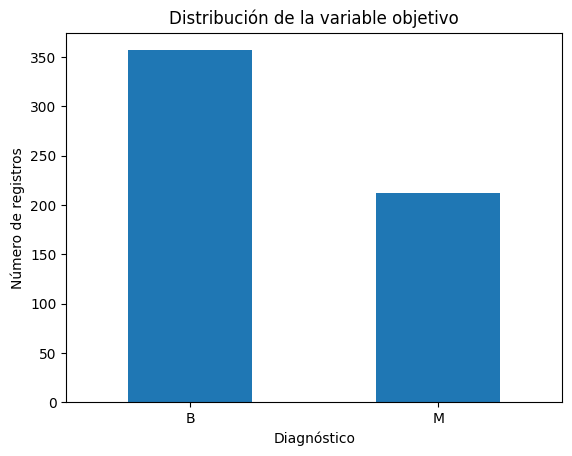

In [ ]:

df["diagnosis"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Diagnóstico")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)
plt.show()



**Interpretación:**  
La variable objetivo contiene más casos benignos que malignos. Debido a esta diferencia entre clases, se utilizará una partición estratificada para mantener proporciones similares en los conjuntos de entrenamiento y prueba.


## 4. Selección de variables predictoras y variable objetivo

In [ ]:

# Se excluye 'id' porque solamente identifica los registros.
# 'diagnosis' se separa como variable objetivo.

X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

# Se conserva una copia de las etiquetas reales.
# Esta copia podrá utilizarse posteriormente para comparar los clusters
# de un análisis no supervisado con los diagnósticos verdaderos.
y_real = y.copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Número de variables predictoras:", X.shape[1])


Dimensiones de X: (569, 30)
Dimensiones de y: (569,)
Número de variables predictoras: 30



Se seleccionaron las 30 variables numéricas como predictoras. La columna `id` no se utiliza porque es solamente un identificador y no describe características de la muestra. La variable `diagnosis` se separa como objetivo y se conserva además una copia de sus valores reales para una futura comparación con los grupos obtenidos mediante técnicas no supervisadas.


## 5. Importancia del escalamiento


Las variables del dataset se encuentran en escalas diferentes. Por ejemplo, las medidas relacionadas con área pueden tomar valores mucho mayores que variables como suavidad o dimensión fractal.

El escalamiento es importante para **SVM** porque la posición de los puntos y las distancias utilizadas para construir la frontera de decisión pueden verse dominadas por las variables de mayor magnitud. También es importante para **K-Means**, ya que este algoritmo forma grupos utilizando distancias entre observaciones.

Se utilizará **StandardScaler**, que transforma cada variable para que tenga aproximadamente media 0 y desviación estándar 1. En los modelos SVM, el escalamiento se incluirá dentro de un **Pipeline**, de manera que el `StandardScaler` se ajuste únicamente con los datos de entrenamiento y se evite fuga de información del conjunto de prueba.


## 6. División en entrenamiento y prueba

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nProporción de clases en entrenamiento:")
print(y_train.value_counts(normalize=True).round(4))

print("\nProporción de clases en prueba:")
print(y_test.value_counts(normalize=True).round(4))


X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)

Proporción de clases en entrenamiento:
diagnosis
B    0.6264
M    0.3736
Name: proportion, dtype: float64

Proporción de clases en prueba:
diagnosis
B    0.6316
M    0.3684
Name: proportion, dtype: float64



Se utiliza 80 % de los registros para entrenamiento y 20 % para prueba. La semilla `random_state=42` permite reproducir la misma partición en ejecuciones posteriores. Además, `stratify=y` conserva aproximadamente la proporción de diagnósticos benignos y malignos en ambos subconjuntos.

Esta división permite evaluar el clasificador con observaciones que no fueron utilizadas durante el entrenamiento, por lo que proporciona una estimación más realista de su capacidad para generalizar a datos nuevos.


## 7. Modelo 1 — SVM con kernel lineal

In [ ]:

modelo_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

modelo_lineal.fit(X_train, y_train)
pred_lineal = modelo_lineal.predict(X_test)

accuracy_lineal = accuracy_score(y_test, pred_lineal)
precision_lineal = precision_score(y_test, pred_lineal, pos_label="M")
recall_lineal = recall_score(y_test, pred_lineal, pos_label="M")
f1_lineal = f1_score(y_test, pred_lineal, pos_label="M")

print("Accuracy:", round(accuracy_lineal, 4))
print("Precision:", round(precision_lineal, 4))
print("Recall:", round(recall_lineal, 4))
print("F1-score:", round(f1_lineal, 4))


Accuracy: 0.9649
Precision: 1.0
Recall: 0.9048
F1-score: 0.95


### Reporte de clasificación — SVM lineal

In [ ]:
print(classification_report(y_test, pred_lineal, digits=4))

              precision    recall  f1-score   support

           B     0.9474    1.0000    0.9730        72
           M     1.0000    0.9048    0.9500        42

    accuracy                         0.9649       114
   macro avg     0.9737    0.9524    0.9615       114
weighted avg     0.9668    0.9649    0.9645       114



### Matriz de confusión — SVM lineal

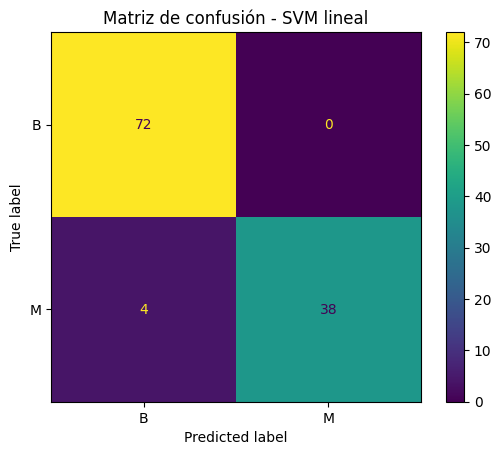

In [ ]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lineal,
    display_labels=["B", "M"]
)
plt.title("Matriz de confusión - SVM lineal")
plt.show()


## 8. Modelo 2 — SVM con kernel RBF

In [ ]:

modelo_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

modelo_rbf.fit(X_train, y_train)
pred_rbf = modelo_rbf.predict(X_test)

accuracy_rbf = accuracy_score(y_test, pred_rbf)
precision_rbf = precision_score(y_test, pred_rbf, pos_label="M")
recall_rbf = recall_score(y_test, pred_rbf, pos_label="M")
f1_rbf = f1_score(y_test, pred_rbf, pos_label="M")

print("Accuracy:", round(accuracy_rbf, 4))
print("Precision:", round(precision_rbf, 4))
print("Recall:", round(recall_rbf, 4))
print("F1-score:", round(f1_rbf, 4))


Accuracy: 0.9737
Precision: 1.0
Recall: 0.9286
F1-score: 0.963


### Reporte de clasificación — SVM RBF

In [ ]:
print(classification_report(y_test, pred_rbf, digits=4))

              precision    recall  f1-score   support

           B     0.9600    1.0000    0.9796        72
           M     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



### Matriz de confusión — SVM RBF

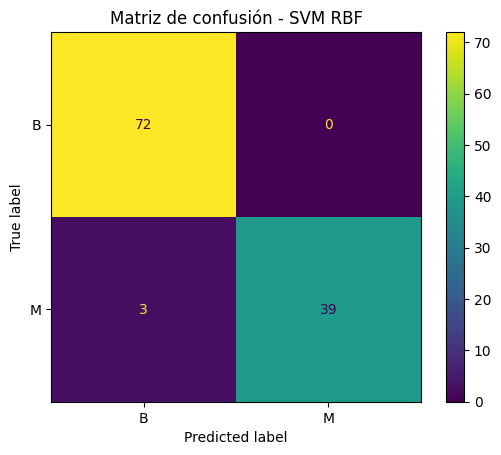

In [ ]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_rbf,
    display_labels=["B", "M"]
)
plt.title("Matriz de confusión - SVM RBF")
plt.show()


## 9. Comparación de resultados

In [ ]:

# Tabla solicitada para comparar ambos modelos SVM

tabla_resultados = pd.DataFrame({
    "Modelo SVM": ["Modelo 1", "Modelo 2"],
    "Kernel": ["Lineal", "RBF"],
    "Accuracy": [accuracy_lineal, accuracy_rbf],
    "Precision": [precision_lineal, precision_rbf],
    "Recall": [recall_lineal, recall_rbf],
    "F1-score": [f1_lineal, f1_rbf]
})

tabla_resultados[["Accuracy", "Precision", "Recall", "F1-score"]] = (
    tabla_resultados[["Accuracy", "Precision", "Recall", "F1-score"]].round(4)
)

tabla_resultados


,Modelo SVM,Kernel,Accuracy,Precision,Recall,F1-score
0,Modelo 1,Lineal,0.9649,1.0,0.9048,0.950
1,Modelo 2,RBF,0.9737,1.0,0.9286,0.963



**Interpretación de las métricas:**  

- **Accuracy** representa la proporción total de diagnósticos clasificados correctamente.
- **Precision** indica qué proporción de las muestras predichas como malignas realmente son malignas.
- **Recall** representa qué proporción de todos los casos malignos reales fue detectada correctamente por el modelo.
- **F1-score** combina precision y recall mediante su media armónica, por lo que ayuda a evaluar el equilibrio entre ambas métricas.

En este problema se considera **M (maligno)** como la clase positiva. Debido a que existen solamente dos clases, no es necesario utilizar promedios `macro` o `weighted` para las métricas principales solicitadas. Estos promedios sí aparecen de manera complementaria en el `classification_report`.


In [ ]:

mejor_modelo = tabla_resultados.loc[tabla_resultados["F1-score"].idxmax()]

print("Modelo con mayor F1-score:")
print(mejor_modelo)


Modelo con mayor F1-score:
Modelo SVM    Modelo 2
Kernel             RBF
Accuracy        0.9737
Precision          1.0
Recall          0.9286
F1-score         0.963
Name: 1, dtype: object


In [ ]:
# Comparar ambos modelos y seleccionar el de mejor desempeño según F1-score

if f1_rbf > f1_lineal:
    mejor_modelo = "SVM con kernel RBF"
    mejor_pred = pred_rbf
    mejor_f1 = f1_rbf
else:
    mejor_modelo = "SVM con kernel lineal"
    mejor_pred = pred_lineal
    mejor_f1 = f1_lineal

print("Mejor modelo:", mejor_modelo)
print("F1-score:", round(mejor_f1, 4))

Mejor modelo: SVM con kernel RBF
F1-score: 0.963


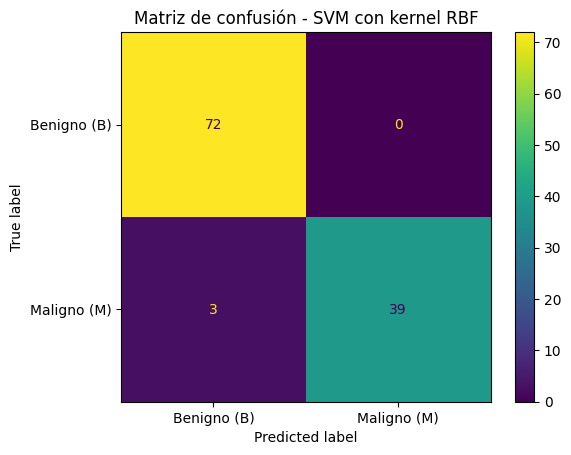

Matriz numérica:
[[72  0]
 [ 3 39]]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    mejor_pred,
    labels=["B", "M"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benigno (B)", "Maligno (M)"]
)

disp.plot()
plt.title(f"Matriz de confusión - {mejor_modelo}")
plt.show()

print("Matriz numérica:")
print(cm)

Interpretación de la matriz de confusión

El modelo tuvo un desempeño bastante bueno. Clasificó correctamente los 72 casos benignos y 39 de los 42 casos malignos. El único error que presentó fue en 3 casos malignos que fueron clasificados como benignos.

Esto muestra que la clase benigna fue más fácil de identificar, ya que no hubo errores en esos casos. En cambio, los casos malignos fueron un poco más difíciles, porque hubo algunos que el modelo confundió con benignos.

Aunque la accuracy del modelo es alta, no es suficiente revisar solo esa métrica, ya que no nos muestra exactamente en qué casos está fallando. La matriz de confusión permite ver que los errores fueron específicamente falsos negativos, lo cual es importante porque significa que algunos casos malignos no fueron detectados por el modelo.

In [ ]:
# Comparación de dos valores de C para el modelo SVM con kernel RBF

modelo_c01 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=0.1))
])

modelo_c10 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10))
])

# Entrenamiento
modelo_c01.fit(X_train, y_train)
modelo_c10.fit(X_train, y_train)

# Predicciones
pred_c01 = modelo_c01.predict(X_test)
pred_c10 = modelo_c10.predict(X_test)

In [ ]:
resultados_c = pd.DataFrame({
    "C": [0.1, 10],
    "Accuracy": [
        accuracy_score(y_test, pred_c01),
        accuracy_score(y_test, pred_c10)
    ],
    "Precision": [
        precision_score(y_test, pred_c01, pos_label="M"),
        precision_score(y_test, pred_c10, pos_label="M")
    ],
    "Recall": [
        recall_score(y_test, pred_c01, pos_label="M"),
        recall_score(y_test, pred_c10, pos_label="M")
    ],
    "F1-score": [
        f1_score(y_test, pred_c01, pos_label="M"),
        f1_score(y_test, pred_c10, pos_label="M")
    ]
})

resultados_c.round(4)

,C,Accuracy,Precision,Recall,F1-score
0,0.1,0.9474,1.0,0.8571,0.9231
1,10.0,0.9737,1.0,0.9286,0.9630


Comparación del hiperparámetro C

Se probaron dos valores diferentes de C en el modelo SVM con kernel RBF. Con C = 0.1, el modelo tuvo un desempeño menor, principalmente en el recall, ya que identificó menos casos malignos correctamente. En cambio, con C = 10 se obtuvo una accuracy de aproximadamente 97.37 % y un mejor F1-score.

El parámetro C controla qué tanto penaliza el modelo los errores de clasificación. Cuando C es pequeño, el modelo permite más errores para mantener un margen más amplio y una frontera más simple. Cuando C aumenta, el modelo intenta clasificar correctamente más observaciones, por lo que el margen puede hacerse más pequeño y la frontera puede ajustarse más a los datos.

Un valor de C demasiado alto puede aumentar el riesgo de sobreajuste, ya que el modelo puede intentar adaptarse demasiado a los datos de entrenamiento. En este caso, C = 10 mejoró el desempeño sin mostrar una caída en las métricas del conjunto de prueba.

En los modelos con kernel RBF, gamma controla qué tanto influye cada observación en la frontera de decisión. Un gamma bajo produce una frontera más suave y general, mientras que un gamma alto genera una frontera más compleja que puede adaptarse mejor a los datos, pero también aumenta el riesgo de sobreajuste.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

# Para K-Means usamos solamente las variables predictoras
# No se incluye diagnosis ni id

X_kmeans = df.drop(columns=["id", "diagnosis"])

scaler_kmeans = StandardScaler()
X_kmeans_scaled = scaler_kmeans.fit_transform(X_kmeans)

print(X_kmeans_scaled.shape)

(569, 30)


Para el análisis no supervisado se eliminaron temporalmente la variable objetivo diagnosis y la columna id. K-Means se aplicó únicamente sobre las 30 variables numéricas escaladas. Las etiquetas reales no se utilizaron para entrenar ni para ajustar el algoritmo.

In [ ]:
valores_k = range(2, 7)

inercias = []
silhouettes = []

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_kmeans_scaled)

    inercias.append(kmeans.inertia_)
    silhouettes.append(
        silhouette_score(X_kmeans_scaled, clusters)
    )

In [ ]:
resultados_k = pd.DataFrame({
    "k": list(valores_k),
    "Inercia": inercias,
    "Silhouette Score": silhouettes
})

resultados_k.round(4)

,k,Inercia,Silhouette Score
0,2,11595.5266,0.3434
1,3,10061.7978,0.3144
2,4,9258.9891,0.2833
3,5,8558.6607,0.1582
4,6,7970.2638,0.1604


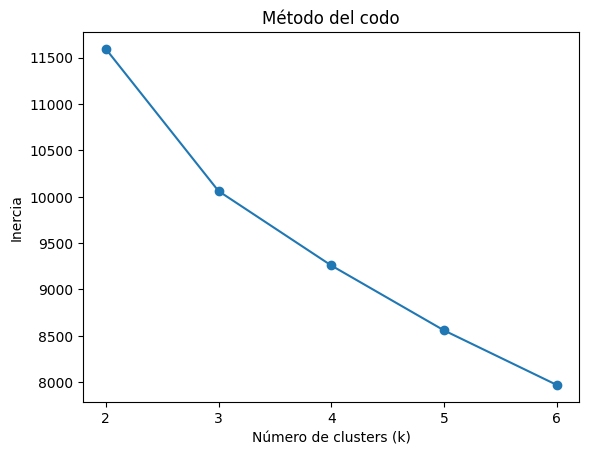

In [ ]:
plt.plot(
    list(valores_k),
    inercias,
    marker="o"
)

plt.title("Método del codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(list(valores_k))
plt.show()

En la gráfica se observa que la inercia disminuye conforme aumenta el número de clusters. La reducción más fuerte se da entre k = 2 y k = 3, y después la disminución se vuelve más gradual. Esto indica que agregar más clusters sigue reduciendo la inercia, pero la mejora ya no es tan marcada.

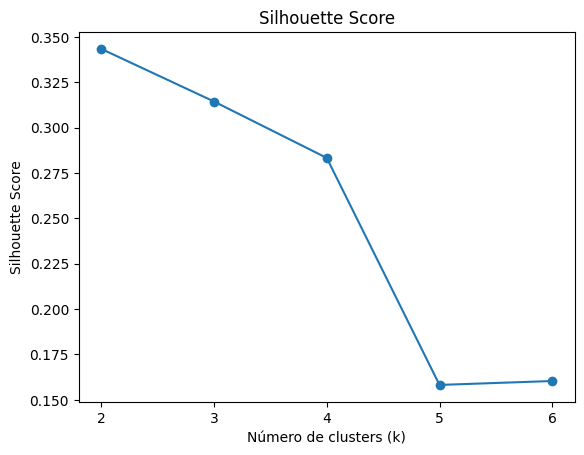

In [ ]:
plt.plot(
    list(valores_k),
    silhouettes,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(valores_k))
plt.show()

El valor más alto de Silhouette Score se obtiene con k = 2, con un valor aproximado de 0.34. A partir de ahí, el puntaje va disminuyendo, lo que indica que los grupos tienen menor separación entre sí conforme aumenta el número de clusters.

Por esta razón, k = 2 se considera la mejor opción, ya que presenta la mejor separación entre los grupos.

### Selección final de k

Tomando en cuenta ambos métodos, se decidió utilizar **k = 2**. El método del codo muestra que la reducción de la inercia es más fuerte en los primeros valores de k y después se vuelve más gradual. Por otro lado, el **Silhouette Score** alcanza su valor más alto con **k = 2**.

Aunque **k = 3** también podría considerarse por el cambio en la inercia, **k = 2** presenta una mejor separación entre los grupos y además mantiene una solución más simple. Por estas razones se seleccionó **k = 2** como el número final de clusters.

In [ ]:
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters_finales = kmeans_final.fit_predict(X_kmeans_scaled)

df_clusters = pd.DataFrame({
    "Cluster": clusters_finales
})

df_clusters["Cluster"].value_counts()

,count
Cluster,
0,375
1,194


Al utilizar k = 2, K-Means formó dos grupos: el cluster 0 con 375 registros y el cluster 1 con 194 registros.

Estos clusters se generaron únicamente con las variables numéricas escaladas y sin utilizar la variable diagnosis, por lo que los grupos fueron encontrados de manera no supervisada.

In [ ]:
# Agregar los clusters al dataframe original
df_resultados = df.copy()
df_resultados["Cluster"] = clusters_finales

# Variables principales para describir los grupos
variables_principales = [
    "mean_radius",
    "mean_texture",
    "mean_area",
    "mean_concavity",
    "mean_concave_points",
    "worst_radius",
    "worst_area"
]

# Promedio de las variables por cluster
tabla_clusters = (
    df_resultados
    .groupby("Cluster")[variables_principales]
    .mean()
    .round(3)
)

# Agregar tamaño de cada cluster
tabla_clusters.insert(
    0,
    "Tamaño",
    df_resultados.groupby("Cluster").size()
)

tabla_clusters

,Tamaño,mean_radius,mean_texture,mean_area,mean_concavity,mean_concave_points,worst_radius,worst_area
Cluster,,,,,,,,
0,375,12.427,18.262,486.772,0.043,0.026,13.768,596.520
1,194,17.415,21.275,979.857,0.178,0.093,21.103,1429.674


Los dos grupos presentan diferencias bastante claras en varias de las características de las muestras. El cluster 0, que contiene la mayor cantidad de registros, agrupa muestras que en general presentan valores menores de radio, área, concavidad y puntos cóncavos. También sus valores máximos de radio y área son considerablemente menores.

Por otro lado, el cluster 1 contiene muestras con dimensiones mayores y con características más irregulares. En este grupo se observan valores más altos de radio y área, además de una mayor concavidad y mayor cantidad de puntos cóncavos.

Esto indica que K-Means no solamente separó las muestras por tamaño, sino también por características relacionadas con la forma de los núcleos celulares. De manera preliminar, se puede decir que un grupo representa muestras con características más pequeñas y regulares, mientras que el otro contiene muestras de mayor tamaño y con formas más irregulares.

Esta interpretación se realiza únicamente con las características encontradas por K-Means. En este punto todavía no se utiliza la variable real de diagnóstico para definir qué representa cada cluster.

In [ ]:
from sklearn.decomposition import PCA

# Reducir las 30 variables escaladas a 2 componentes
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_kmeans_scaled)

print("Varianza explicada por PC1:", round(pca.explained_variance_ratio_[0], 4))
print("Varianza explicada por PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Varianza explicada total:",
      round(pca.explained_variance_ratio_.sum(), 4))

Varianza explicada por PC1: 0.4427
Varianza explicada por PC2: 0.1897
Varianza explicada total: 0.6324


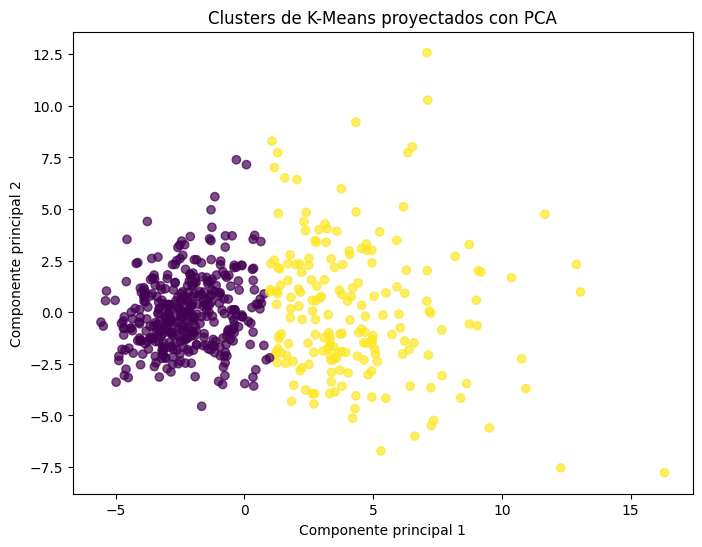

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_finales,
    alpha=0.7
)

plt.title("Clusters de K-Means proyectados con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

plt.show()

En esta gráfica se observan los dos grupos encontrados por K-Means después de reducir las 30 variables a dos componentes principales mediante PCA. Se puede ver una separación bastante clara entre ambos clusters, principalmente a lo largo del primer componente principal, aunque existe una zona donde algunos puntos se encuentran más cerca entre sí.

Esto indica que K-Means logró encontrar dos patrones diferentes dentro de los datos. Un grupo se concentra principalmente en la parte izquierda de la gráfica, mientras que el otro se encuentra más distribuido hacia la derecha.

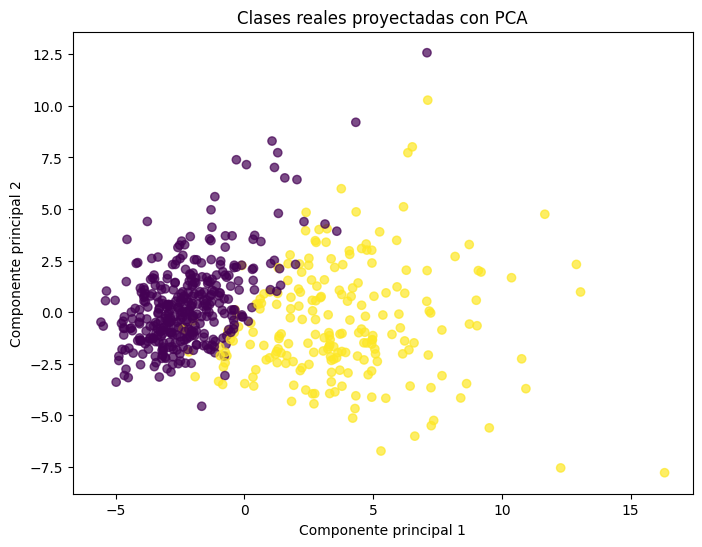

In [ ]:
# Convertir las etiquetas reales únicamente para poder colorear la gráfica
colores_reales = y_real.map({
    "B": 0,
    "M": 1
})

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=colores_reales,
    alpha=0.7
)

plt.title("Clases reales proyectadas con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

plt.show()

En esta gráfica se muestran las clases reales del dataset utilizando la misma proyección de PCA. Visualmente se observa un patrón parecido al obtenido con K-Means: una gran parte de una clase se concentra hacia la izquierda y la otra aparece principalmente hacia la derecha.

Sin embargo, también existe una zona donde ambas clases se mezclan, lo que indica que algunas muestras tienen características similares aunque pertenezcan a diagnósticos diferentes. Las etiquetas reales se utilizaron únicamente para esta comparación visual y no participaron en el entrenamiento de K-Means.

Al comparar ambas gráficas, se puede ver que los clusters encontrados automáticamente por K-Means tienen una distribución bastante similar a la de las clases reales. Esto sugiere que las variables del dataset contienen patrones naturales que ayudan a separar los distintos tipos de muestras, aunque la coincidencia no es perfecta.

In [ ]:
# Comparación entre clusters y clases reales

comparacion = pd.crosstab(
    clusters_finales,
    y_real,
    rownames=["Cluster"],
    colnames=["Diagnóstico real"]
)

comparacion

Diagnóstico real,B,M
Cluster,,
0,339,36
1,18,176


In [ ]:
comparacion_porcentaje = pd.crosstab(
    clusters_finales,
    y_real,
    rownames=["Cluster"],
    colnames=["Diagnóstico real"],
    normalize="index"
) * 100

comparacion_porcentaje.round(2)

Diagnóstico real,B,M
Cluster,,
0,90.40,9.60
1,9.28,90.72


Al comparar los grupos encontrados por K-Means con los diagnósticos reales, se puede ver que sí existe una correspondencia bastante clara entre ambos.

El cluster 0 está formado principalmente por casos benignos, ya que 339 de sus 375 registros son benignos. Por otro lado, el cluster 1 contiene principalmente casos malignos, con 176 de 194 registros pertenecientes a esta clase.

Aun así, la separación no es perfecta. En el cluster 0 aparecen 36 casos malignos y en el cluster 1 aparecen 18 casos benignos. Esto muestra que existen algunas muestras cuyas características numéricas son parecidas a las del otro grupo.

No se espera que K-Means reproduzca exactamente las etiquetas de benigno y maligno, porque el algoritmo no conoce el diagnóstico al momento de formar los grupos. K-Means solamente agrupa las observaciones según qué tan similares son sus características y las distancias entre ellas. Por eso, aunque los clusters presentan una relación bastante fuerte con las clases reales, no tienen que coincidir completamente con ellas.

En este caso, los resultados sugieren que las características numéricas del dataset contienen una estructura natural bastante relacionada con el diagnóstico, incluso cuando esta información no se proporciona al algoritmo.

## Exportación del dataset procesado

Como parte de la entrega, se genera una versión procesada del dataset que conserva las variables originales y agrega el **cluster asignado por K-Means**. La variable de diagnóstico no se utilizó para entrenar K-Means; únicamente se conserva en el archivo para facilitar análisis y comparaciones posteriores.

In [ ]:
# Guardar el dataset procesado con el cluster asignado
df_resultados.to_csv("wdbc_procesado.csv", index=False)

print("Archivo generado: wdbc_procesado.csv")
print("Dimensiones:", df_resultados.shape)

# En Google Colab puedes descargarlo desde el panel de archivos.
# Si quieres forzar la descarga, puedes descomentar estas dos líneas:
# from google.colab import files
# files.download("wdbc_procesado.csv")

# Conclusión

En esta actividad se utilizaron dos enfoques diferentes de aprendizaje automático: SVM como método supervisado y K-Means como método no supervisado.

El enfoque que dio resultados más fáciles de interpretar fue SVM, porque trabaja con clases conocidas y permite medir directamente qué tan bien predice si una muestra es benigna o maligna. Además, métricas como accuracy, precision, recall, F1-score y la matriz de confusión permitieron identificar con claridad tanto los aciertos como los errores del modelo.

SVM mostró que las características numéricas del dataset permiten predecir el diagnóstico con un desempeño bastante alto. También permitió observar que algunos casos malignos son más difíciles de distinguir, ya que hubo algunos falsos negativos.

Por otro lado, K-Means permitió encontrar patrones sin utilizar la variable de diagnóstico. El algoritmo identificó dos grupos con diferencias claras en características como tamaño, área y concavidad. Al comparar posteriormente estos clusters con las clases reales, se observó una correspondencia bastante fuerte, aunque no perfecta.

Una de las principales limitaciones es que K-Means no conoce las etiquetas reales, por lo que sus grupos no tienen por qué representar exactamente benigno y maligno. Además, su resultado depende de las distancias entre los datos y de la cantidad de clusters seleccionada. En el caso de SVM, aunque el desempeño fue alto, todavía existieron algunos errores y también es necesario elegir correctamente parámetros como C, gamma y el kernel.

En conclusión, SVM sería más útil cuando ya se conocen las clases y se quiere predecir la categoría de nuevos registros. En cambio, K-Means sería útil cuando no existen etiquetas y se desea explorar los datos para encontrar grupos, similitudes o patrones que no se conocen previamente.

De esta forma, el aprendizaje supervisado busca aprender a predecir una respuesta conocida, mientras que el aprendizaje no supervisado busca descubrir la estructura que existe dentro de los datos sin depender de una etiqueta previa.

## Fuentes consultadas

- **UCI Machine Learning Repository.** *Breast Cancer Wisconsin (Diagnostic) Dataset (WDBC).*  
  https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- **Scikit-learn.** Documentación de `SVC` (Support Vector Classification).  
  https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- **Scikit-learn.** Documentación de `KMeans`.  
  https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
- **Scikit-learn.** Documentación de `StandardScaler`.  
  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- **Scikit-learn.** Documentación de `PCA`.  
  https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- **Scikit-learn.** Documentación de `silhouette_score`.  
  https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html